# **Sentimental Analysis on Amazon Product Reviews**

In [1]:
!pip install textblob

**Import Libraries**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
print("Import Successful")

Import Successful


**Load Dataset**

In [4]:
df=pd.read_csv("Reviews.csv")

In [5]:
df=df.head(5000)

**Data Exploration**

In [6]:
df.head(10)
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      5000 non-null   int64 
 1   ProductId               5000 non-null   object
 2   UserId                  5000 non-null   object
 3   ProfileName             5000 non-null   object
 4   HelpfulnessNumerator    5000 non-null   int64 
 5   HelpfulnessDenominator  5000 non-null   int64 
 6   Score                   5000 non-null   int64 
 7   Time                    5000 non-null   int64 
 8   Summary                 5000 non-null   object
 9   Text                    5000 non-null   object
dtypes: int64(5), object(5)
memory usage: 390.8+ KB


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,2500.500000,1.580200,2.067200,4.150400,1.294930e+09
std,1443.520003,5.584533,6.288672,1.326549,4.802063e+07
min,1.000000,0.000000,0.000000,1.000000,9.617184e+08
25%,1250.750000,0.000000,0.000000,4.000000,1.271376e+09
50%,2500.500000,0.000000,1.000000,5.000000,1.309219e+09
75%,3750.250000,2.000000,2.000000,5.000000,1.330301e+09
max,5000.000000,187.000000,216.000000,5.000000,1.351210e+09


**Data Cleaning**

In [7]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,0
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,0
Text,0


In [8]:
df=df.dropna(subset=["Text"])

In [9]:
df = df.drop_duplicates(subset=["Text"])

In [10]:
df = df[["Text", "Score"]]

In [11]:
df.shape

(4984, 2)

**Checking Rating Distribution**

In [12]:
df["Score"].value_counts()

,count
Score,
5,3126
4,711
1,467
3,393
2,287


**Plot Rating Distribution**

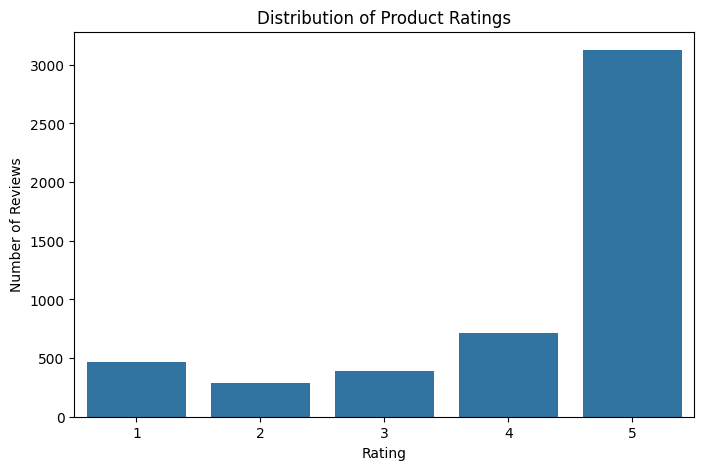

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x="Score", data=df)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

In [14]:
df["Review_Length"] = df["Text"].apply(len)

In [15]:
df["Review_Length"].mean()

np.float64(407.24378009630817)

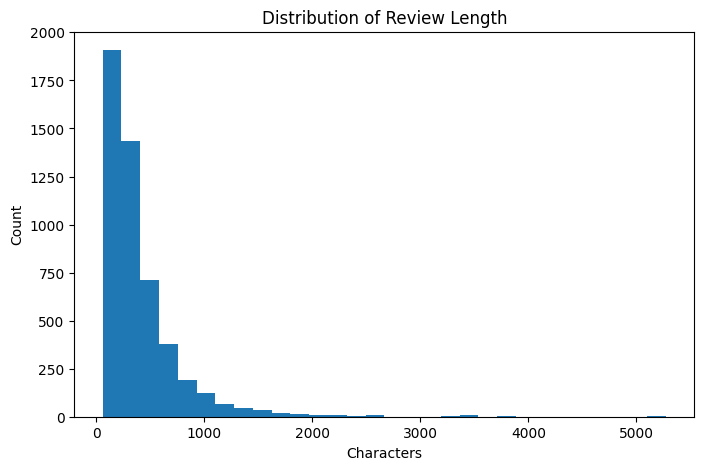

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df["Review_Length"], bins=30)
plt.title("Distribution of Review Length")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

**Sentiment Analysis**

In [17]:
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [18]:
df["Sentiment"] = df["Text"].apply(get_sentiment)

In [19]:
df.head(10)

,Text,Score,Review_Length,Sentiment
0,I have bought several of the Vitality canned d...,5,263,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,190,Negative
2,This is a confection that has been around a fe...,4,509,Positive
3,If you are looking for the secret ingredient i...,2,219,Positive
4,Great taffy at a great price. There was a wid...,5,140,Positive
5,I got a wild hair for taffy and ordered this f...,4,416,Positive
6,This saltwater taffy had great flavors and was...,5,304,Positive
7,This taffy is so good. It is very soft and ch...,5,140,Positive
8,Right now I'm mostly just sprouting this so my...,5,131,Positive
9,This is a very healthy dog food. Good for thei...,5,137,Positive


**Data Visualization**

Sentiment Distribution Bar Chart

/tmp/ipykernel_3500/579024516.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Sentiment", data=df, palette="Set2")


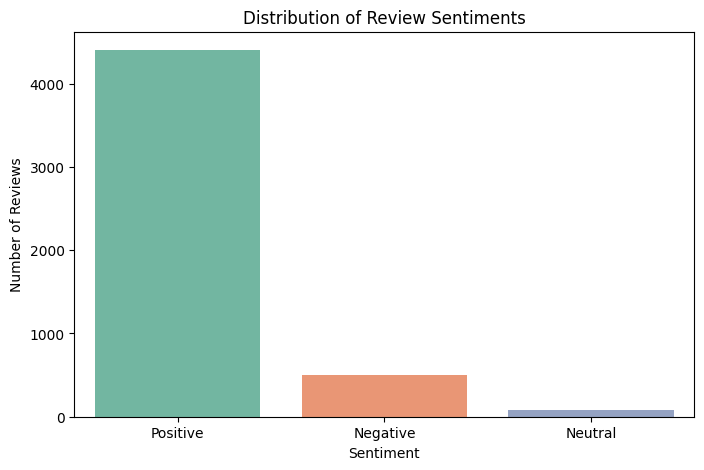

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x="Sentiment", data=df, palette="Set2")
plt.title("Distribution of Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.savefig("sentiment_bar.png", dpi=300, bbox_inches="tight")
plt.show()

Sentiment Percentage Pie Chart

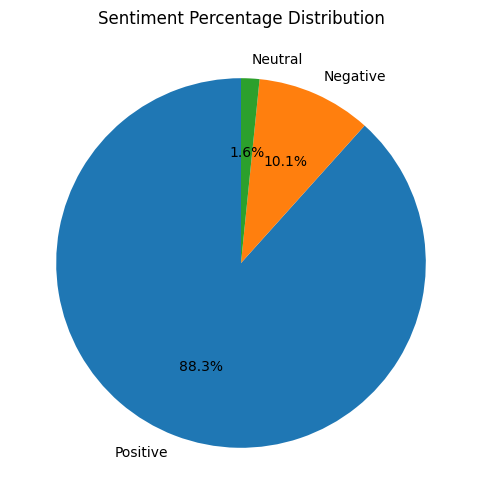

In [21]:
sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sentiment Percentage Distribution")

plt.savefig("sentiment_pie.png", dpi=300, bbox_inches="tight")
plt.show()

Rating vs Sentiment

<Figure size 1000x600 with 0 Axes>

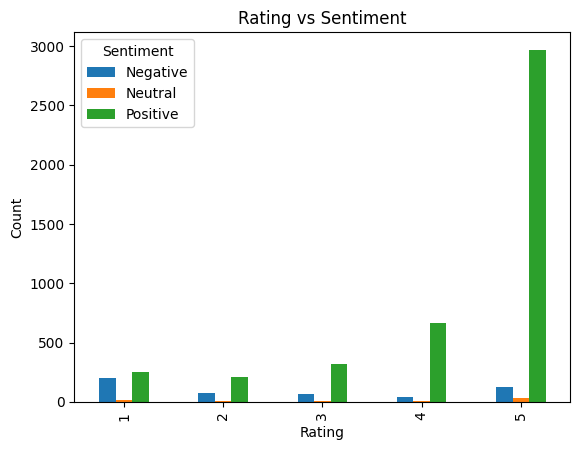

In [22]:
plt.figure(figsize=(10,6))

pd.crosstab(df["Score"], df["Sentiment"]).plot(kind="bar")

plt.title("Rating vs Sentiment")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.savefig("rating_vs_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,4403
Negative,501
Neutral,80


In [24]:
positive_percentage = (
    (df["Sentiment"] == "Positive").mean()
) * 100

print(f"Positive Reviews: {positive_percentage:.2f}%")

Positive Reviews: 88.34%


In [25]:
negative_percentage = (
    (df["Sentiment"] == "Negative").mean()
) * 100

print(f"Negative Reviews: {negative_percentage:.2f}%")

Negative Reviews: 10.05%


In [26]:
neutral_percentage = (
    (df["Sentiment"] == "Neutral").mean()
) * 100

print(f"Neutral Reviews: {neutral_percentage:.2f}%")

Neutral Reviews: 1.61%


In [28]:
df.to_csv("Reviews_5000.csv", index=False)
